In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[0]  # importing functions from other folders
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from _data.data_utils import read_in
from _fitting.fitting_utils import hist_plot, CI_plot, CI_plot_alt, CI_plot_both, plot_posteriors_side_by_side, plot_spline_Bknots
import pymc as pm
import pymc.math as pmm
import arviz as az
from patsy import dmatrix
import nutpie
import time
from IPython.display import display
from pymc.variational.callbacks import CheckParametersConvergence
import io
import base64

az.style.use("arviz-darkgrid")


if '___laptop' in os.listdir('../'):
    # laptop folder
    folder = "../../_data/p-dengue/"
elif '___server' in os.listdir('../'):
    # server folder
    folder = "../../../../../data/lucaratzinger_data/p_dengue/"

Uncovering the effect of different modelling choices for splines

Curve has mean -1.597


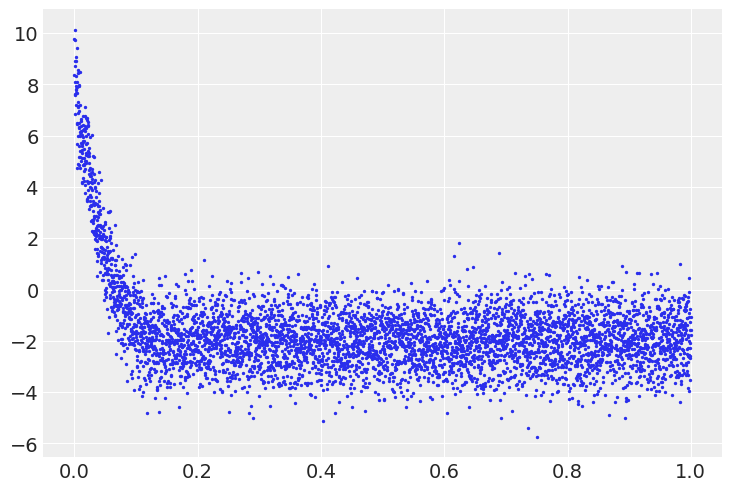

In [2]:
np.random.seed(0)
l = 5000
x = np.linspace(0, 1, l)[::]
_ = dmatrix(f"bs(s, knots=knots, degree=degree, include_intercept=True)-1",
                {"s": x, "knots": np.percentile(x, np.linspace(0, 100, 5 + 2))[1:-1], "degree":3})
y = _[:, 0] + 0.1*np.random.randn(l)
y = 10*y -2
print(f'Curve has mean {y.mean():.3f}')
plt.scatter(x, y, marker='o', label='Data', s=2)
plt.show()

Curve has mean 1.019


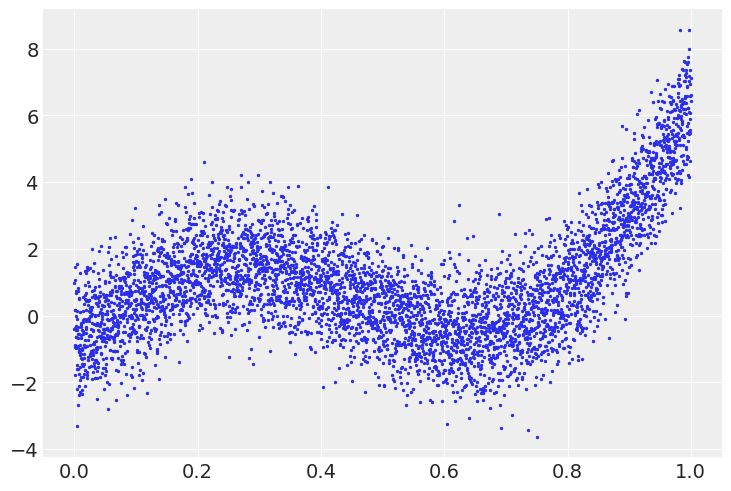

In [3]:
np.random.seed(0)
l = 5000
x = np.linspace(0, 1, l)[::]
y = 0.2*np.sin(2 * np.pi * x) + 0.1*np.random.randn(l) + x**3 - 0.5*x**2 + 0.2*x + 0.12
y = 10*y -2
print(f'Curve has mean {y.mean():.3f}')
plt.scatter(x, y, marker='o', label='Data', s=2)
plt.show()

In [3]:
num_knots = 5
degree = 3

---

B_full has shape (5000, 9)
B_drop has shape (5000, 8)


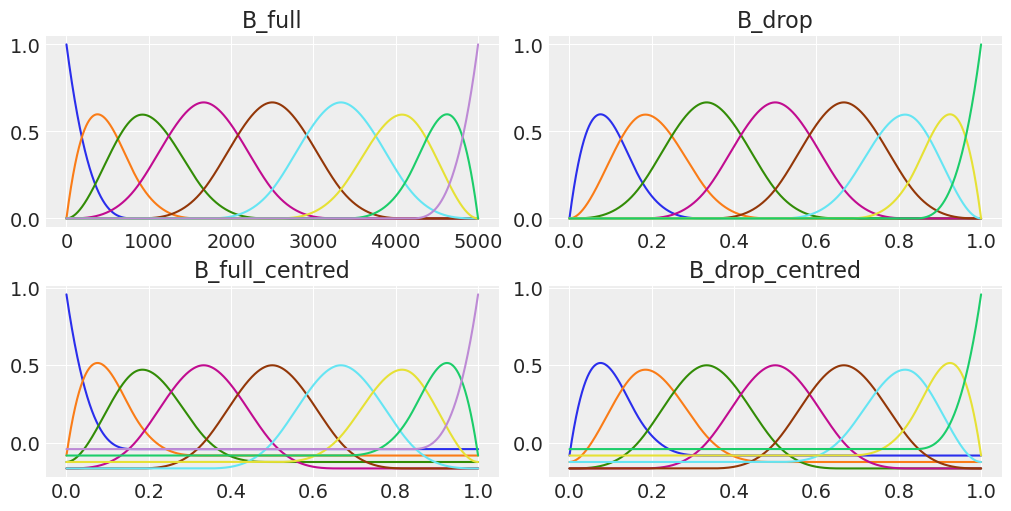

In [4]:
d = x.copy()
knot_list = np.percentile(d, np.linspace(0, 100, num_knots + 2))[1:-1]

B_full = dmatrix(f"bs(s, knots=knots, degree=degree, include_intercept=True)-1",
                {"s": d, "knots": knot_list, "degree":degree})
B_full_centred = B_full - B_full.mean(axis=0)  # centre the spline basis functions
B_full_std = B_full_centred / B_full_centred.std(axis=0)  # standardise the spline basis functions
B_full_centred_unit = B_full_centred / (np.max(B_full_centred, axis=0) - np.min(B_full_centred, axis=0))  # standardise the spline basis functions to unit range
print(f'B_full has shape {B_full.shape}')

B_drop = dmatrix(f"bs(s, knots=knots, degree=degree, include_intercept=False)-1",
                {"s": d, "knots": knot_list, "degree":degree})
B_drop_centred = B_drop - B_drop.mean(axis=0)  # centre the spline basis functions
B_drop_std = B_drop_centred / B_drop_centred.std(axis=0)  # standardise the spline basis functions
B_drop_centred_unit = B_drop_centred / (np.max(B_drop_centred, axis=0) - np.min(B_drop_centred, axis=0))  # standardise the spline basis functions to unit range
print(f'B_drop has shape {B_drop.shape}')


fig, axes = plt.subplots(2, 2, figsize=(10, 5))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]
#ax5 = axes[2, 0]
#ax6 = axes[2, 1]
#ax7 = axes[3, 0]
#ax8 = axes[3, 1]

ax1.plot(B_full)
ax1.set_title('B_full')
ax2.plot(x, B_drop)
ax2.set_title('B_drop')
ax3.plot(x, B_full_centred)
ax3.set_title('B_full_centred')
ax4.plot(x, B_drop_centred)
ax4.set_title('B_drop_centred')
#ax5.plot(x, B_full_std)
#ax5.set_title('B_full_std')
#ax7.plot(x, B_full_centred_unit)
#ax7.set_title('B_full_centred_unit')
#ax8.plot(x, B_drop_centred_unit)
#ax8.set_title('B_drop_centred_unit')
#ax6.plot(x, B_drop_std)
#ax6.set_title('B_drop_std')
plt.show()


U has shape (5000, 9), S has shape (9,), Vt has shape (9, 9)
Rank of B_full_centred is 8
X_r has shape (5000, 8)


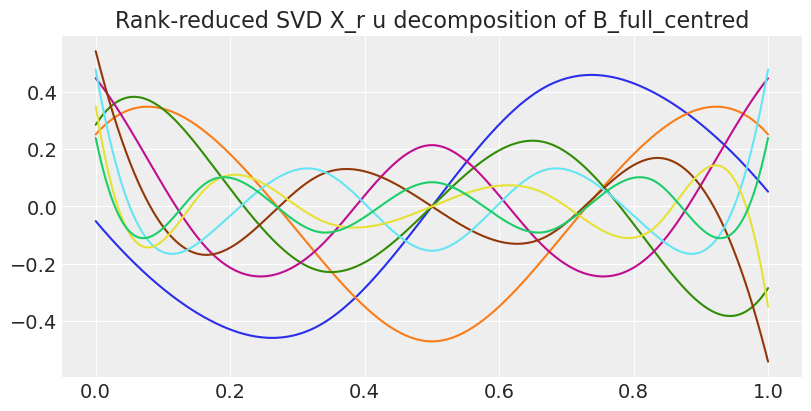

In [5]:
U, S, Vt = np.linalg.svd(B_full_centred, full_matrices=False)
print(f'U has shape {U.shape}, S has shape {S.shape}, Vt has shape {Vt.shape}')
r = np.sum(S > 1e-10)
print(f'Rank of B_full_centred is {r}')
U_r = U[:, :r]
S_r = S[:r]
X_r = U_r @ np.diag(S_r)
print(f'X_r has shape {X_r.shape}')

plt.figure(figsize=(8, 4))
plt.title('Rank-reduced SVD X_r u decomposition of B_full_centred')
plt.plot(x, X_r)
plt.show()

---

In [6]:
def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=150)
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode("utf-8")
    plt.close(fig)
    return img_base64

def go(m, stat_name='rh', var_names=['intercept', 'sigma', 'sigma_w', 'w']):
    with model_dict[m]:
        s0 = time.time()
        idata_dict[m] = pm.sample(
            tune=1000,
            draws=4000,
            chains=4,
            discard_tuned_samples=True,
            nuts_sampler="nutpie",
            store_divergences=True
        )
        s1 = time.time()

        pm.compute_log_likelihood(idata_dict[m], progressbar=False)
        s2 = time.time()

        time_dict[m] = (s1 - s0, s2 - s1)

    # ---------- Summary table ----------
    summary_df = az.summary(idata_dict[m], var_names=var_names)
    summary_html = summary_df.to_html()

    # ---------- Trace plot ----------
    fig_trace = az.plot_trace(idata_dict[m], var_names=var_names)
    fig_trace = fig_trace.ravel()[0].figure
    trace_img = fig_to_base64(fig_trace)

    # ---------- Pair plot ----------
    az.rcParams["plot.max_subplots"] = 200
    ax = az.plot_pair(
        idata_dict[m],
        var_names=var_names,
        textsize=14,
        divergences=True
    )

    for i in range(ax.shape[0]):
        ax[i, 0].yaxis.label.set_rotation(0)
        ax[i, 0].yaxis.label.set_ha('right')

    for j in range(ax.shape[1]):
        ax[0, j].xaxis.label.set_rotation(45)
        ax[0, j].xaxis.label.set_ha('right')

    fig_pair = ax.ravel()[0].figure
    pair_img = fig_to_base64(fig_pair)

    # ---------- Spline plot ----------
    fig_spline = plot_spline_Bknots(
        idata_dict[m],
        stat_name,
        'w',
        'sigma_w',
        B_dict[m],
        x,
        knots=knot_list,
        show_basis=True,
        invert_log=True,
        centred_w=centred_dict[m]
    )
    spline_img = fig_to_base64(fig_spline)

    # ---------- Build HTML ----------
    html_content = f"""
    <html>
    <head>
        <title>Model Report: {m}</title>
        <style>
            body {{ font-family: Arial; margin: 40px; }}
            h1 {{ margin-bottom: 10px; }}
            img {{ margin-top: 20px; max-width: 100%; }}
            table {{ border-collapse: collapse; }}
            th, td {{ padding: 6px 8px; }}
        </style>
    </head>
    <body>
        <h1>Model Report: {m}</h1>

        <h2>Timing</h2>
        <p>Posterior Sampling: {time_dict[m][0]:.2f} seconds</p>
        <p>Log Likelihood Compute: {time_dict[m][1]:.2f} seconds</p>

        <h2>Summary</h2>
        {summary_html}

        <h2>Trace Plot</h2>
        <img src="data:image/png;base64,{trace_img}">

        <h2>Pair Plot</h2>
        <img src="data:image/png;base64,{pair_img}">

        <h2>Spline Plot</h2>
        <img src="data:image/png;base64,{spline_img}">
    </body>
    </html>
    """

    with open(f"{m}.html", "w") as f:
        f.write(html_content)

    print(f"Saved report to {m}.html")


In [7]:
def go_light(m, var_names=['intercept', 'sigma', 'sigma_w', 'w']):
    with model_dict[m]:
        s0 = time.time()
        idata_dict[m] = pm.sample(tune=1000, draws=4000, chains=4, random_seed=4,
                                    discard_tuned_samples=True, nuts_sampler="nutpie", store_divergences=True)
        s1 = time.time()
        pm.compute_log_likelihood(idata_dict[m], progressbar=False)
        s2 = time.time()
        time_dict[m] = (s1 - s0, s2 - s1)
        print(f'Posterior Sampling {s1 - s0:.2f} seconds')
        print(f'Log Likelihood Compute {s2 - s1:.2f} seconds')
        
    var_names = ['intercept', 'sigma', 'sigma_w', 'w']
    display(az.summary(idata_dict[m], var_names=var_names))
    az.plot_trace(idata_dict[m], var_names=var_names);

    plot_spline_Bknots(idata_dict[m], 'tp', 'w', 'sigma_w',
            B_dict[m], x,
            knots=knot_list,
            show_basis=True, basis_scale=1, invert_log=False);
    # 0.01
    var_names = ['intercept', 'sigma', 'sigma_w', 'w']
    az.rcParams["plot.max_subplots"] = 200
    ax = az.plot_pair(idata_dict[m], var_names=var_names, textsize=20, divergences=True)

    for i in range(ax.shape[0]):
        # Left-hand side (row labels / y-axis labels)
        ax[i, 0].yaxis.label.set_rotation(0)  # e.g., vertical left labels
        ax[i, 0].yaxis.label.set_ha('right')  # horizontal alignment

    for j in range(ax.shape[1]):
        # Top (column labels / x-axis labels)
        ax[0, j].xaxis.label.set_rotation(45)  # e.g., rotate top labels
        ax[0, j].xaxis.label.set_ha('right')

In [8]:
def compare_models(models_list, iter):
    # Compare models
    times = {m: [] for m in models_list}
    for m in models_list:
        for i in range(iter):
            with model_dict[m]:
                s0 = time.time()
                idata_dict[m] = pm.sample(tune=1000, draws=4000, chains=4, progressbar=False,
                                            discard_tuned_samples=True, nuts_sampler="nutpie", store_divergences=True)
                s1 = time.time()
                pm.compute_log_likelihood(idata_dict[m], progressbar=False)
                s2 = time.time()
                times[m].append(s1 - s0)
        print(f"Model {m}: Mean time = {np.mean(times[m]):.2f} seconds")
    mean_times = {m: np.mean(times[m]) for m in models_list}
    return times, mean_times 

In [9]:
from multiprocessing import Pool
import numpy as np
import time
import pymc as pm

def _compare_worker(task):
    m, iter = task
    times, mean_times = compare_models([m], iter)
    return m, times[m], mean_times[m]


def compare_models_parallel(models_list, iter, n_workers=4):

    tasks = [(m, iter) for m in models_list]
    with Pool(n_workers) as p:
        results = p.map(_compare_worker, tasks)

    # Reassemble results
    times = {}
    mean_times = {}

    for m, t, mt in results:
        times[m] = t
        mean_times[m] = mt
    return times, mean_times

In [10]:
model_dict = {}
B_dict = {}
idata_dict = {}
time_dict = {}
centred_dict = {}

---

## Models

In [12]:
m = "B non-centred full (f mean redistribution)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    intercept_ = pm.Normal("intercept_", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfStudentT(f"sigma_w", nu=1.0, sigma=1.0)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full.shape[1], dims='splines')
    f = pm.math.dot(B_full, w)
    f_mean = pm.math.mean(f)
    f = f - f_mean  # hard constraint to force f to have zero mean

    intercept = pm.Deterministic("intercept", intercept_ + f_mean)  # redistribute the mean of f to the intercept
    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full

In [11]:
m = "B non-centred full (linearly constrained gaussian)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfStudentT(f"sigma_w", nu=1.0, sigma=1.0)

    w_ = pm.Normal(f"w_", mu=0, sigma=sigma_w, shape=B_full.shape[1], dims='splines')
    ones = np.ones((B_full.shape[0], 1))
    S = np.eye(B_full.shape[1]) - B_full.T@ones@np.linalg.inv(ones.T@B_full@B_full.T@ones)@ones.T@B_full
    w = pm.Deterministic("w", pm.math.dot(S, w_))
    f = pm.math.dot(B_full, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full

In [23]:
m = "B non-centred full (linearly constrained gaussian)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfStudentT(f"sigma_w", nu=1.0, sigma=1.0)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full.shape[1], dims='splines')
    ones = np.ones((B_full.shape[0], 1))
    S = np.eye(B_full.shape[1]) - B_full.T@ones@np.linalg.inv(ones.T@B_full@B_full.T@ones)@ones.T@B_full
    w_ = pm.Deterministic("w_", pm.math.dot(S, w))
    f = pm.math.dot(B_full, w_)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full

In [24]:
go(m)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,5000,0,0.17,31
,5000,0,0.17,143
,5000,0,0.20,79
,5000,0,0.18,15


Saved report to B non-centred full (linearly constrained gaussian).html


In [11]:
ones = np.ones((B_full.shape[0], 1))
S = np.eye(B_full.shape[1]) - B_full.T@ones@np.linalg.inv(ones.T@B_full@B_full.T@ones)@ones.T@B_full

In [17]:
v = np.zeros((B_full.shape[1], 1))
v[0,0] = 1
v += -np.mean(B_full[:, 0])

In [22]:
S@v - v

array([[ 0.00000000e+00],
       [ 3.46944695e-17],
       [ 2.08166817e-17],
       [-4.16333634e-17],
       [-5.55111512e-17],
       [-4.16333634e-17],
       [ 2.77555756e-17],
       [ 2.77555756e-17],
       [ 0.00000000e+00]])

In [15]:
B_full@S@np.ones((B_full.shape[1], 1))

array([[0.68342872],
       [0.68229498],
       [0.6811626 ],
       ...,
       [0.6811626 ],
       [0.68229498],
       [0.68342872]])

In [13]:
go(m)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,5000,0,0.18,15
,5000,0,0.16,31
,5000,0,0.12,31
,5000,0,0.14,15


Saved report to B non-centred full (linearly constrained gaussian).html


In [50]:
m = "B centred full SVD X_r u decomposition"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfStudentT(f"sigma_w", nu=1.0, sigma=1.0)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=X_r.shape[1], dims='splines')
    f = pm.math.dot(X_r, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = X_r

In [51]:
m = "B non-centred full"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfStudentT(f"sigma_w", nu=1.0, sigma=1.0)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full.shape[1], dims='splines')
    f = pm.math.dot(B_full, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full

In [52]:
m = "B non-centred full (hard f zero mean constraint)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfStudentT(f"sigma_w", nu=1.0, sigma=1.0)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full.shape[1], dims='splines')
    f = pm.math.dot(B_full, w)
    f = f - pm.math.mean(f)  # hard constraint to force f to have zero mean

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full

In [53]:
m = "B non-centred full (soft w zero mean constraint)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfStudentT(f"sigma_w", nu=1.0, sigma=1.0)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full.shape[1], dims='splines')
    pm.Potential(f"w_centred_prior", pm.logp(pm.Normal.dist(mu=0.0, sigma=1e-2), pm.math.mean(w)))
    f = pm.math.dot(B_full, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full

In [54]:
m = "B non-centred full (soft f zero mean constraint)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfStudentT(f"sigma_w", nu=1.0, sigma=1.0)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full.shape[1], dims='splines')
    f = pm.math.dot(B_full, w)
    f_mean = pm.math.mean(f)  # hard constraint to force f to have zero mean
    pm.Potential(f"f_centred_prior", pm.logp(pm.Normal.dist(mu=0.0, sigma=1e-3), f_mean))

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full

In [55]:
m = "B non-centred full (soft f range scaled zero mean constraint)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfStudentT(f"sigma_w", nu=1.0, sigma=1.0)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full.shape[1], dims='splines')
    f = pm.math.dot(B_full, w)
    f_mean = pm.math.mean(f)  # hard constraint to force f to have zero mean
    f_min, f_max = pm.math.min(f), pm.math.max(f)
    pm.Potential(f"f_centred_prior", pm.logp(pm.Normal.dist(mu=0.0, sigma=1e-2), f_mean/(pmm.abs(f_max - f_min) + 1e-6)))

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full

In [56]:
m = "B non-centred full (soft f sd scaled zero mean constraint)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfStudentT(f"sigma_w", nu=1.0, sigma=1.0)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full.shape[1], dims='splines')
    f = pm.math.dot(B_full, w)
    f_mean = pm.math.mean(f)  # hard constraint to force f to have zero mean
    f_sd = pm.math.sqrt(pm.math.sum(pm.math.sqr(f - f_mean))/(f.shape[0]-1))
    pm.Potential(f"f_centred_prior", pm.logp(pm.Normal.dist(mu=0.0, sigma=1e-2), f_mean/(f_sd + 1e-6)))

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full

In [57]:
m = "B centred full"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfStudentT(f"sigma_w", nu=1.0, sigma=1.0)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full_centred.shape[1], dims='splines')
    f = pm.math.dot(B_full_centred, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full_centred

In [58]:
m = "B centred full (soft w constraint)"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfStudentT(f"sigma_w", nu=1.0, sigma=1.0)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_full_centred.shape[1], dims='splines')
    pm.Potential(f"w_centred_prior", pm.logp(pm.Normal.dist(mu=0.0, sigma=1e-2), pm.math.mean(w)))
    f = pm.math.dot(B_full_centred, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_full_centred

In [59]:
m = "B centred drop"

model = pm.Model()
with model:
    # Priors
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=2.0)

    # Spline coefficients
    sigma_w = pm.HalfStudentT(f"sigma_w", nu=1.0, sigma=1.0)

    w = pm.Normal(f"w", mu=0, sigma=sigma_w, shape=B_drop_centred.shape[1], dims='splines')
    f = pm.math.dot(B_drop_centred, w)

    mu = intercept + f

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

model_dict[m] = model
centred_dict[m] = True
B_dict[m] = B_drop_centred

In [61]:
t, mean_times = compare_models_parallel(list(model_dict.keys()), iter=20, n_workers=10)

Model B centred full SVD X_r u decomposition: Mean time = 4.50 seconds
Model B centred drop: Mean time = 5.22 seconds
Model B centred full (soft w constraint): Mean time = 5.74 seconds
Model B non-centred full (soft w zero mean constraint): Mean time = 6.15 seconds
Model B non-centred full (soft f sd scaled zero mean constraint): Mean time = 6.97 seconds
Model B non-centred full (soft f range scaled zero mean constraint): Mean time = 8.60 seconds
Model B centred full: Mean time = 10.46 seconds
Model B non-centred full (hard f zero mean constraint): Mean time = 10.99 seconds
Model B non-centred full: Mean time = 12.72 seconds
Model B non-centred full (soft f zero mean constraint): Mean time = 16.11 seconds


In [20]:
t, mean_t = compare_models(list(model_dict.keys()), iter=10)

Model B non-centred full: Mean time = 8.98 seconds
Model B non-centred full (hard f zero mean constraint): Mean time = 8.78 seconds
Model B non-centred full (soft w zero mean constraint): Mean time = 6.24 seconds
Model B non-centred full (soft f zero mean constraint): Mean time = 11.18 seconds
Model B non-centred full (soft f range scaled zero mean constraint): Mean time = 8.67 seconds
Model B non-centred full (soft f sd scaled zero mean constraint): Mean time = 8.09 seconds
Model B centred full: Mean time = 9.13 seconds
Model B centred full (soft w constraint): Mean time = 6.83 seconds
Model B centred drop: Mean time = 6.59 seconds
